# Continuous vs. Discrete Time Stochastic System Simulation (Basics)

## Learning Objectives
* Understand the mathematical difference between Stochastic Differential Equations (SDEs) and Difference Equations.
* Learn how to simulate continuous-time processes using `sdeint`.
* Implement discrete-time approximations (Euler-Maruyama) manually.
* Visualize and compare the path properties of continuous vs. discrete simulation.

## 1. Theoretical Background

### Continuous-Time Dynamics (SDEs)
A continuous-time stochastic system differs from an Ordinary Differential Equation (ODE) by the inclusion of a random noise term. It is formally written as a Stochastic Differential Equation (SDE):

$$
dX_t = f(X_t, t)dt + g(X_t, t)dW_t
$$

Where:
* $f(X_t, t)$ is the **drift** (deterministic part).
* $g(X_t, t)$ is the **diffusion** (stochastic part).
* $W_t$ is a **Wiener process** (Brownian motion), representing continuous-time noise.

The generic solution involves Ito calculus. Unlike ODEs, the "derivative" $dW_t/dt$ does not strictly exist in the classical sense because Brownian motion is nowhere differentiable.

### Discrete-Time Dynamics
Digital computers cannot handle true continuity. To simulate an SDE, we must **discretize** it. The most common method is the **Euler-Maruyama approximation**:

$$
X_{k+1} = X_k + f(X_k, t_k)\Delta t + g(X_k, t_k) \Delta W_k
$$

Where $\Delta W_k \sim \mathcal{N}(0, \Delta t)$. In practice, we generate standard normal random variables $\xi_k \sim \mathcal{N}(0, 1)$ and scale them:

$$
\Delta W_k = \sqrt{\Delta t} \cdot \xi_k
$$


In [1]:
# Install sdeint if not already installed
%pip install sdeint

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sdeint
import warnings
import random 
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
# Set seed for reproducibility
np.random.seed(42)

%matplotlib inline

## 2. Continuous-Time Simulation with `sdeint`

We will simulate a simple linear SDE (Langevin Equation / Ornstein-Uhlenbeck process):

$$
dX_t = -\theta X_t dt + \sigma dW_t
$$

Although we perform this numerically (which implies some internal discretization), `sdeint` handles the higher-order integration schemes (like Ito or Stratonovich) to closely approximate the continuous trajectory.

Initial condition: 0.0


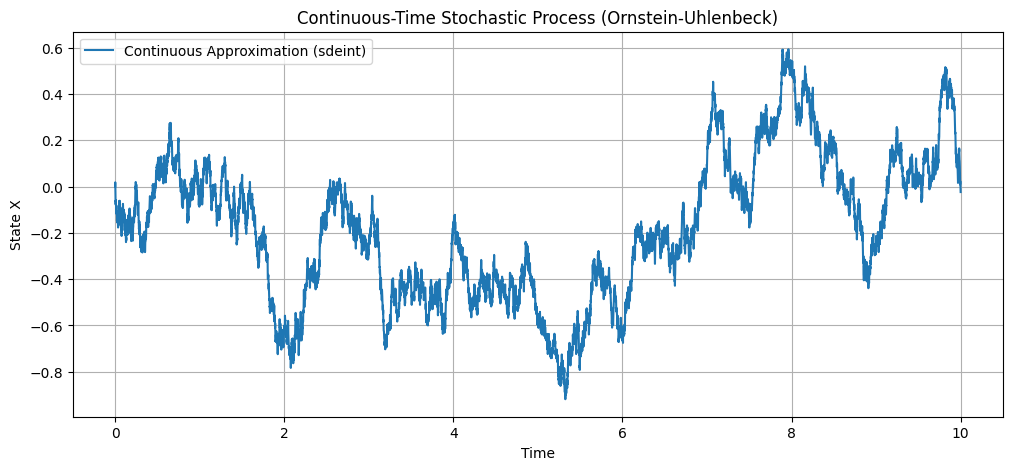

In [3]:
# System Parameters
theta = 1.0  # Drift coefficient (mean reversion)
sigma = 0.5  # Diffusion coefficient (noise intensity)
# x0 = np.random.ranf()    # Initial condition
x0=0.0

# Time span
T = 10.0
dt_fine = 0.001  # Very fine step for "continuous" ground truth
t_span = np.arange(0, T, dt_fine)

# Define Drift and Diffusion functions for sdeint
def f(x, t):
    return -theta * x

def g(x, t):
    return sigma

# Integrate
result_sdeint = sdeint.itoint(f, g, x0, t_span)
print(f"Initial condition: {x0}")
# Plot
plt.figure(figsize=(12, 5))
plt.plot(t_span, result_sdeint, label='Continuous Approximation (sdeint)')
plt.title('Continuous-Time Stochastic Process (Ornstein-Uhlenbeck)')
plt.xlabel('Time')
plt.ylabel('State X')
plt.legend()
plt.grid(True)
plt.show()

## 3. Discrete-Time Implementation (Euler-Maruyama)

The Euler-Maruyama method is the simplest numerical scheme for SDEs. For an SDE $dX_t = f(X_t)dt + g(X_t)dW_t$, the discrete approximation over a step $\Delta t$ is:
$$
X_{k+1} = X_k + f(X_k) \Delta t + g(X_k) \Delta W_k
$$
where $\Delta W_k$ represents the Brownian increment. Crucially, strictly $\Delta W_k \sim \mathcal{N}(0, \Delta t)$. In simulation, we typically generate a standard normal variable $Z \sim \mathcal{N}(0, 1)$ and set $\Delta W_k = Z \sqrt{\Delta t}$.

Now we explicitly simulate the discrete-time difference equation using this method. We will use a larger time step $\Delta t$ to show how the discrete system behaves compared to the fine-grained continuous one.

Key Equation for code:
`x[k+1] = x[k] - theta * x[k] * dt + sigma * np.sqrt(dt) * np.random.randn()`

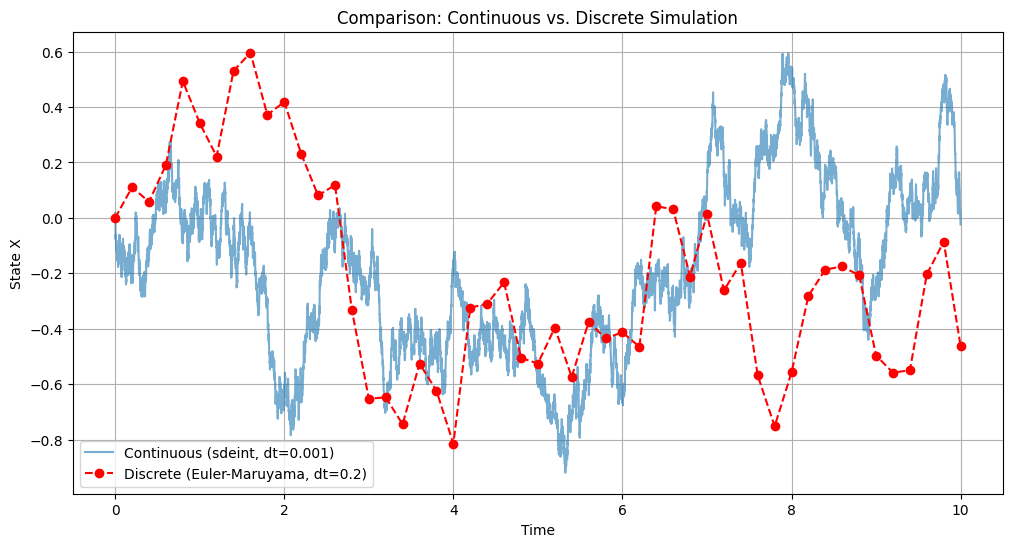

In [4]:
# Discrete Time Parameters
dt_coarse = 0.2  # Larger time step
steps = int(T / dt_coarse)
t_discrete = np.linspace(0, T, steps + 1)

x_discrete = np.zeros(steps + 1)
x_discrete[0] = x0

# TODO: Implement the Euler-Maruyama loop
# Students can try writing this loop themselves first

for k in range(steps):
    # Standard normal random variable
    xi = np.random.randn()
    
    # Compute update
    # Note: The noise is scaled by sqrt(dt)
    drift_term = -theta * x_discrete[k] * dt_coarse
    diff_term = sigma * np.sqrt(dt_coarse) * xi
    
    x_discrete[k+1] = x_discrete[k] + drift_term + diff_term

# Visualization Comparison
plt.figure(figsize=(12, 6))
plt.plot(t_span, result_sdeint, alpha=0.6, label='Continuous (sdeint, dt=0.001)')
plt.plot(t_discrete, x_discrete, 'o--', color='red', label=f'Discrete (Euler-Maruyama, dt={dt_coarse})')
plt.title('Comparison: Continuous vs. Discrete Simulation')
plt.xlabel('Time')
plt.ylabel('State X')
plt.legend()
plt.grid(True)
plt.show()

### Observation
Notice that the discrete simulation captures the general trend but "misses" the high-frequency variation between the larger time steps. Also, note that while we call one "continuous", it is just a very fine discretization (dt=0.001) vs a coarse one (dt=0.2). 

The crucial takeaway is that the noise scaling $\sqrt{\Delta t}$ is what maintains statistical consistency across different time steps.

## 4. Student Exercise

### Task 1: Sensitivity to Time Step
Change `dt_coarse` to `1.0` and observe what happens to the stability of the solution. Then try `0.01`.

### Task 2: Brownian Motion
Set `theta = 0` (no drift) in both the `sdeint` function and your manual loop. The system becomes a pure Brownian Motion (Random Walk). Run the simulation again.

### Solution: Task 1 — Sensitivity to Time Step

We run the Euler-Maruyama simulation with three different time steps to show stability / accuracy trade-offs:
- `dt = 0.01` (fine → close to the continuous reference)
- `dt = 0.2`  (coarse, same as Section 3)
- `dt = 1.0`  (very coarse → large jumps, possible instability)

**Observation:** larger $\\Delta t$ introduces bigger discretisation errors. For the OU process the critical stability limit is $\\Delta t < 2/\\theta$, so with $\\theta = 1$ any step $\\geq 2$ will diverge.

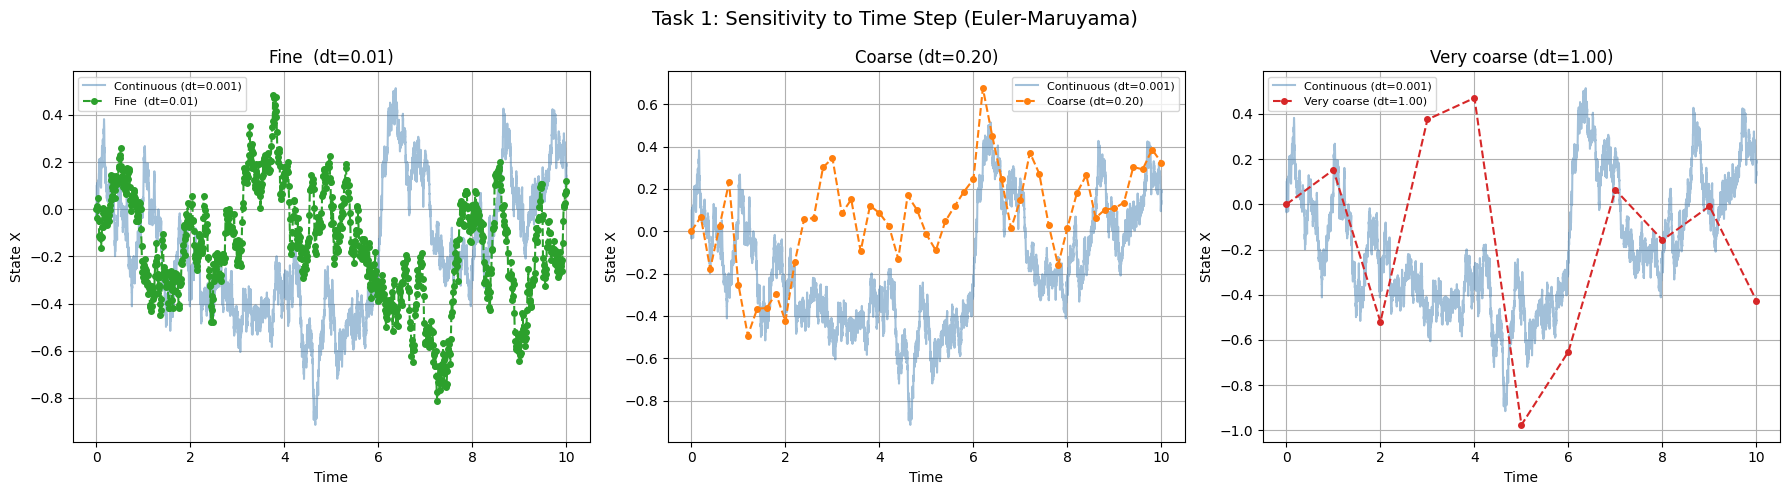

Key takeaways:
  dt=0.01 → fine; closely tracks continuous reference.
  dt=0.20 → coarse; misses high-frequency detail.
  dt=1.00 → very coarse; large discrete jumps, may look unstable.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sdeint
import warnings
warnings.filterwarnings('ignore')

# ── shared parameters (same as Sections 2 & 3) ──────────────────────
np.random.seed(42)
theta = 1.0    # mean-reversion strength
sigma = 0.5    # diffusion intensity
x0    = 0.0    # initial condition
T     = 10.0   # total time

# Continuous-time reference
dt_fine = 0.001
t_span  = np.arange(0, T, dt_fine)

def f(x, t): return -theta * x
def g(x, t): return sigma

result_sdeint = sdeint.itoint(f, g, x0, t_span)

# ── Euler-Maruyama helper ────────────────────────────────────────────
def euler_maruyama(dt, theta, sigma, x0, T, seed=42):
    rng   = np.random.default_rng(seed)
    steps = int(T / dt)
    t_arr = np.linspace(0, T, steps + 1)
    x_arr = np.zeros(steps + 1)
    x_arr[0] = x0
    for k in range(steps):
        xi           = rng.standard_normal()
        x_arr[k + 1] = x_arr[k] - theta * x_arr[k] * dt + sigma * np.sqrt(dt) * xi
    return t_arr, x_arr

# ── simulate with three step sizes ──────────────────────────────────
configs = [
    (0.01,  'tab:green',  'Fine  (dt=0.01)'),
    (0.20,  'tab:orange', 'Coarse (dt=0.20)'),
    (1.00,  'tab:red',    'Very coarse (dt=1.00)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle('Task 1: Sensitivity to Time Step (Euler-Maruyama)', fontsize=14)

for ax, (dt_val, color, label) in zip(axes, configs):
    t_em, x_em = euler_maruyama(dt_val, theta, sigma, x0, T)
    ax.plot(t_span, result_sdeint, alpha=0.5, color='steelblue',
            label=f'Continuous (dt={dt_fine})')
    ax.plot(t_em, x_em, 'o--', color=color, markersize=4, label=label)
    ax.set_title(label)
    ax.set_xlabel('Time')
    ax.set_ylabel('State X')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

print('Key takeaways:')
print('  dt=0.01 → fine; closely tracks continuous reference.')
print('  dt=0.20 → coarse; misses high-frequency detail.')
print('  dt=1.00 → very coarse; large discrete jumps, may look unstable.')

### Solution: Task 2 — Pure Brownian Motion

Setting $\\theta = 0$ removes the mean-reversion term:

$$dX_t = \\sigma\\,dW_t$$

Key properties of a **Wiener process** (scaled by $\\sigma$):
- No restoring force; the path wanders freely (non-stationary).
- Variance grows linearly with time: $\\operatorname{Var}(X_t) = \\sigma^2 t$.
- Paths are continuous but nowhere differentiable.

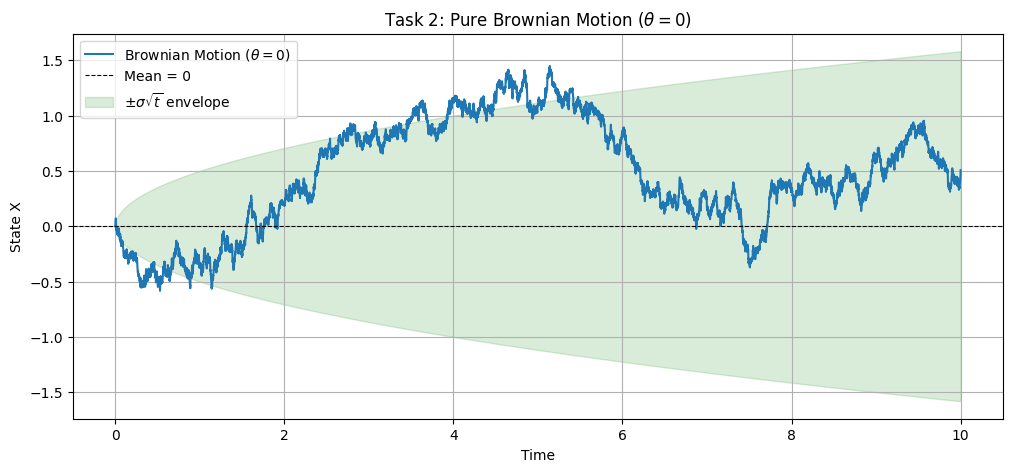

Final value            : 0.5066
Theoretical std at T=10.0: sigma*sqrt(T) = 1.5811


In [6]:
# ── Task 2: Pure Brownian Motion (theta = 0) ────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import sdeint
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

sigma  = 0.5
x0     = 0.0
T      = 10.0
dt     = 0.001
t_span = np.arange(0, T, dt)

def f_bm(x, t): return 0.0   # theta = 0 → no drift
def g_bm(x, t): return sigma

result_bm = sdeint.itoint(f_bm, g_bm, x0, t_span)

# 1-sigma theoretical envelope: std(X_t) = sigma * sqrt(t)
std_env = sigma * np.sqrt(t_span)

plt.figure(figsize=(12, 5))
plt.plot(t_span, result_bm, label=r'Brownian Motion ($\theta=0$)')
plt.axhline(0, color='k', linewidth=0.8, linestyle='--', label='Mean = 0')
plt.fill_between(t_span, -std_env, std_env, alpha=0.15, color='green',
                 label=r'$\pm\sigma\sqrt{t}$ envelope')
plt.title(r'Task 2: Pure Brownian Motion ($\theta = 0$)')
plt.xlabel('Time')
plt.ylabel('State X')
plt.legend()
plt.grid(True)
plt.show()

print(f'Final value            : {result_bm[-1][0]:.4f}')
print(f'Theoretical std at T={T}: sigma*sqrt(T) = {sigma * np.sqrt(T):.4f}')

### Comparison: Ornstein-Uhlenbeck vs. Brownian Motion

| Property | OU Process ($\\theta > 0$) | Brownian Motion ($\\theta = 0$) |
|---|---|---|
| **Drift** | $-\\theta X_t$ (restoring) | None |
| **Stationary?** | Yes (stable distribution) | No (unbounded) |
| **Long-run variance** | $\\sigma^2 / (2\\theta)$ | $\\sigma^2 t \\to \\infty$ |
| **Application** | Interest rates, tracking error | Stock prices, particle diffusion |

In estimation theory, the OU process is commonly used as a **process noise model** for signals known to be mean-reverting.